In [13]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import xarray as xr
import geopandas as gpd
import cartopy.crs as ccrs

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size' : 18})

# Functions

# Load in Data

In [14]:
# Define filepaths
root_dir = Path().resolve().parents[0]
wrf_fpath = root_dir / 'data' / '03_processed' / 'wrf-fog-cldfra.nc'
met_fpath = root_dir / 'data' / '03_processed' / 'combined-sites-clean.csv'
station_fpath = root_dir / 'data' / '01_raw' / 'weather-station-coords' /'sci-stations.shp'

## Load in WRF Data
wrf_fog_ds = xr.open_dataset(wrf_fpath)
#wrf_fog_ds = wrf_fog_ds.rename({'__xarray_dataarray_variable__' : 'fog-cldfra'})

# Remove duplicates
wrf_fog_ds = wrf_fog_ds.groupby('time').mean()

# Create binary fog/no fog based on previously identified threshold
wrf_fog_ds['wrf-fog-binary'] = xr.where(wrf_fog_ds['fog-cldfra'] > .125, 1, 0)

## Load in Weather Station Locations
station_gdf = gpd.read_file(station_fpath)

## Load in Weather Station Data
met_df = pd.read_csv(met_fpath)
met_df['time (PST)'] = pd.to_datetime(met_df['time (PST)'])
met_df['time (PST)'] = met_df['time (PST)'] - pd.to_timedelta(1, unit='h')
met_df = met_df.rename({'time (PST)' : 'time (PDT)'}, axis=1)
met_df = met_df.set_index(['site', 'time (PDT)'])

# Subset and resample to match WRF hourly timestep
met_fog = met_df[['fog tips']]
met_fog = met_fog.groupby(['site', pd.Grouper(freq='h', level='time (PDT)')]).sum()
met_fog['fog-binary'] = met_fog['fog tips'].apply(lambda x: 1 if x > 0 else 0)
met_fog.head()



fog tips  fog-binary
site time (PDT)                               
cair 2004-04-30 23:00:00       0.0           0
     2004-05-01 00:00:00       0.0           0
     2004-05-01 01:00:00       0.0           0
     2004-05-01 02:00:00       0.0           0
     2004-05-01 03:00:00       0.0           0

# Analyses and figures for paper


### Extract WRF values for each site

In [15]:
# Extract WRF data for each site
wrf_fog_df = pd.DataFrame()
for i, row in station_gdf.iterrows():
    wrf_station_df = wrf_fog_ds.sel(lat=row['latitude'], lon=row['longitude'], method='nearest')
    wrf_station_df = wrf_station_df.to_dataframe().drop(['lat', 'lon'], axis=1)
    wrf_station_df['site'] = row['station']
    wrf_fog_df = pd.concat([wrf_fog_df, wrf_station_df])

wrf_fog_df = wrf_fog_df.reset_index().rename({'time' : 'time (PDT)'}, axis=1)
wrf_fog_df = wrf_fog_df.set_index(['site', 'time (PDT)'])

# Join observed vs. modeled data
join_df = met_fog[['fog tips', 'fog-binary']].join(wrf_fog_df, how='inner')
join_df.head(2)

fog tips  fog-binary  fog-cldfra  wrf-fog-binary
site time (PDT)                                                           
cair 2004-04-30 23:00:00       0.0           0         0.0               0
     2004-05-01 00:00:00       0.0           0         0.0               0

In [16]:
# Ensure summer months only
join_df = join_df.loc[join_df.index.get_level_values('time (PDT)').month.isin([5,6,7,8,9])]  # ensure only summer months

# Check for very short monthly records
monthly_counts = join_df.groupby(pd.Grouper(level='time (PDT)', freq='ME')).size()
monthly_counts = monthly_counts.loc[monthly_counts.values != 0]
print(monthly_counts.loc[monthly_counts.values < 10])

# Remove days with only 1 or 2 observations
join_df = join_df.loc[~join_df.index.get_level_values('time (PDT)').normalize().isin([pd.to_datetime('2010-06-30'), pd.to_datetime('2011-05-31')])]

time (PDT)
2010-06-30    1
2011-05-31    2
dtype: int64


In [17]:
# Check that it looks as expected
join_df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 85761 entries, ('cair', Timestamp('2004-05-01 00:00:00')) to ('wrdg', Timestamp('2006-09-30 16:00:00'))
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fog tips        85761 non-null  float64
 1   fog-binary      85761 non-null  int64  
 2   fog-cldfra      85761 non-null  float32
 3   wrf-fog-binary  85761 non-null  int64  
dtypes: float32(1), float64(1), int64(2)
memory usage: 5.2+ MB


### Plot frequencies by site/month/year

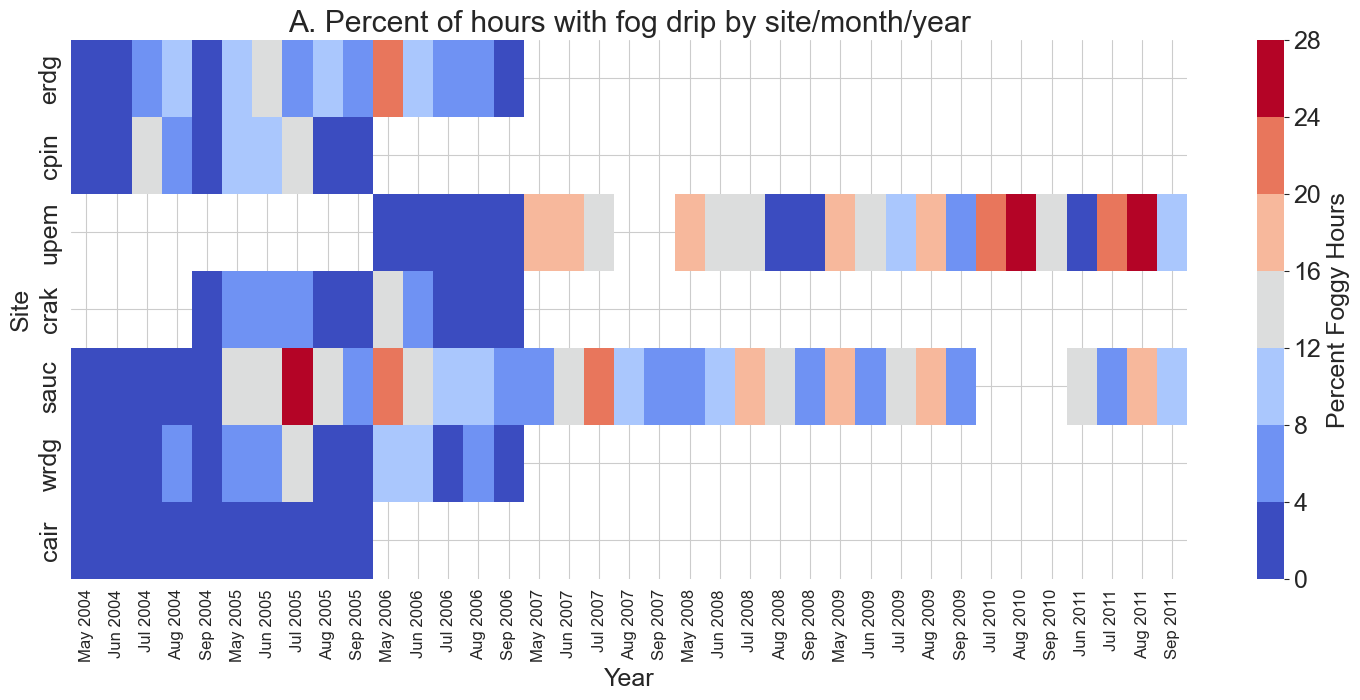

In [18]:
df_gp = join_df.groupby(['site', pd.Grouper(freq='ME', level='time (PDT)')]).sum()
df_count = join_df.groupby(['site', pd.Grouper(freq='ME', level='time (PDT)')]).count()
df_gp = df_gp / df_count * 100

df_gp = df_gp[['fog-binary', 'wrf-fog-binary']].reset_index()
df_gp['year'] = df_gp['time (PDT)'].dt.year
df_gp['diff'] =  df_gp['wrf-fog-binary'] - df_gp['fog-binary']
df_gp

site_order = ['cair', 'wrdg', 'sauc', 'crak', 'upem','cpin', 'erdg']  # Ordered West -> East
df = df_gp[['site', 'time (PDT)', 'fog-binary']]
heatmap_data = df.pivot(index='site', columns='time (PDT)', values='fog-binary')
heatmap_data = heatmap_data.loc[site_order[::-1]]  # Orders the rows by W -> E going up

fig, ax = plt.subplots(figsize=(18,7))
levels = np.arange(0,32,4)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

sns.heatmap(heatmap_data, annot=False, fmt='.2f', cmap='coolwarm', norm=norm, cbar_kws={'label' : 'Percent Foggy Hours'}, ax=ax)
ax.set(title='A. Percent of hours with fog drip by site/month/year',
       xlabel='Year',
       ylabel='Site')
ax.set_xticklabels(
    [pd.to_datetime(t.get_text()).strftime('%b %Y') for t in ax.get_xticklabels()],
    rotation=90,
    fontsize=12
)
plt.show()

In [19]:
# Correlations
stats_df = pd.DataFrame()
for site in df_gp['site'].unique():
    site_df = df_gp.loc[df_gp['site'] == site]
    corr = np.corrcoef(site_df['fog-binary'], site_df['wrf-fog-binary'])[0, 1]
    
    bias = np.mean((site_df['wrf-fog-binary'] - site_df['fog-binary']))
    rmse = np.sqrt(np.mean((site_df['wrf-fog-binary'] - site_df['fog-binary'])**2))

    stat_dict = {
        'site' : site,
        'correlation' : round(corr, 2),
        'bias' : round(bias, 2),
        'rmse' : round(rmse, 2)
        }
    site_stats = pd.DataFrame([stat_dict])
    stats_df = pd.concat([stats_df, site_stats], axis=0)


site_order = ['cair', 'wrdg', 'sauc', 'crak', 'upem', 'cpin', 'erdg']
stats_df['site'] = pd.Categorical(stats_df['site'], categories=site_order, ordered=True)
stats_df = stats_df.sort_values('site').reset_index(drop=True)


stats_df.T

,0,1,2,3,4,5,6
site,cair,wrdg,sauc,crak,upem,cpin,erdg
correlation,0.19,0.49,0.03,-0.23,0.24,0.14,0.15
bias,5.05,0.71,0.91,1.35,-7.17,-2.22,-4.25
rmse,6.42,3.97,8.5,6.04,11.1,5.32,7.24


### Plot modeled - observed for site/month/year

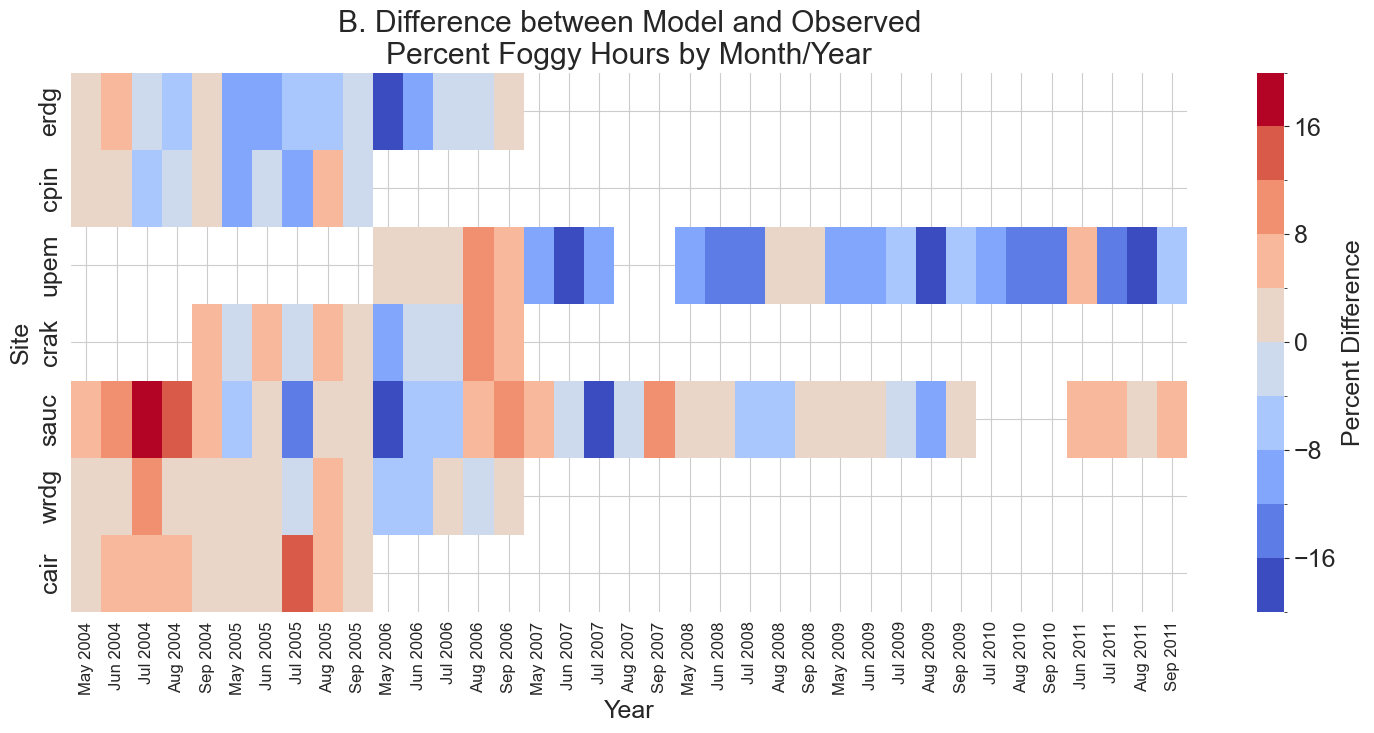

In [20]:
df_gp = join_df.groupby(['site', pd.Grouper(freq='ME', level='time (PDT)')]).sum()
df_count = join_df.groupby(['site', pd.Grouper(freq='ME', level='time (PDT)')]).count()
df_gp = df_gp / df_count * 100

df_gp = df_gp[['fog-binary', 'wrf-fog-binary']].reset_index()
df_gp['year'] = df_gp['time (PDT)'].dt.year
df_gp['diff'] =  df_gp['wrf-fog-binary'] - df_gp['fog-binary']
df_gp

site_order = ['cair', 'wrdg', 'sauc', 'crak', 'upem','cpin', 'erdg']  # Ordered West -> East
df = df_gp[['site', 'time (PDT)', 'diff']]
heatmap_data = df.pivot(index='site', columns='time (PDT)', values='diff')
heatmap_data = heatmap_data.loc[site_order[::-1]]  # Orders the rows by W -> E going up

fig, ax = plt.subplots(figsize=(18,7))
levels = np.arange(-20,24,4)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

sns.heatmap(heatmap_data, annot=False, fmt='.2f', cmap='coolwarm', norm=norm, cbar_kws={'label' : 'Percent Difference'}, ax=ax)
ax.set(title='B. Difference between Model and Observed\nPercent Foggy Hours by Month/Year',
       xlabel='Year',
       ylabel='Site')
ax.set_xticklabels(
    [pd.to_datetime(t.get_text()).strftime('%b %Y') for t in ax.get_xticklabels()],
    rotation=90,
    fontsize=12
)
plt.show()

## Overall frequency bar plot

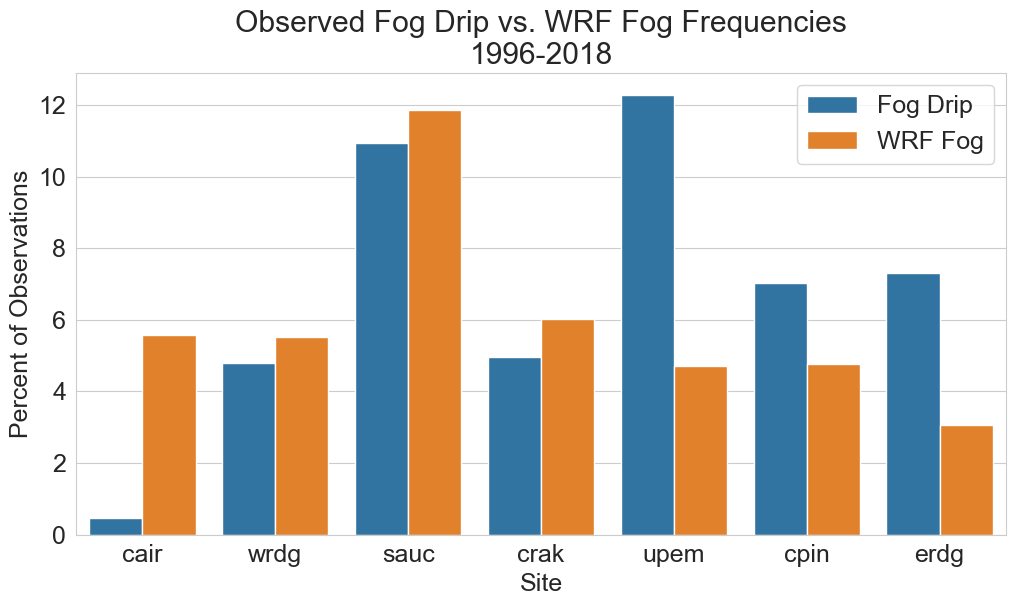

In [34]:
df_gp = join_df[['fog-binary', 'wrf-fog-binary']].groupby('site').sum()
df_count = join_df[['fog-binary', 'wrf-fog-binary']].groupby('site').count()
df_gp = df_gp / df_count * 100
df_gp = df_gp.reset_index()

df_gp = df_gp.melt(id_vars='site', value_vars=['fog-binary', 'wrf-fog-binary'], var_name='source', value_name='count')


# Plot frequencies
site_order = ['cair', 'wrdg', 'sauc', 'crak', 'upem','cpin', 'erdg']  # Ordered West -> East
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(df_gp,
            x='site',
            y='count',
            hue='source',
            order=site_order)
ax.set(title=f'Observed Fog Drip vs. WRF Fog Frequencies\n{min_year}-{max_year}',
       xlabel='Site',
       ylabel='Percent of Observations')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Fog Drip', 'WRF Fog'], title='')

plt.show()

# Additional Analyses
These were not included in the manuscript and may be unorganized. 

## Visualize WRF Fog Patterns

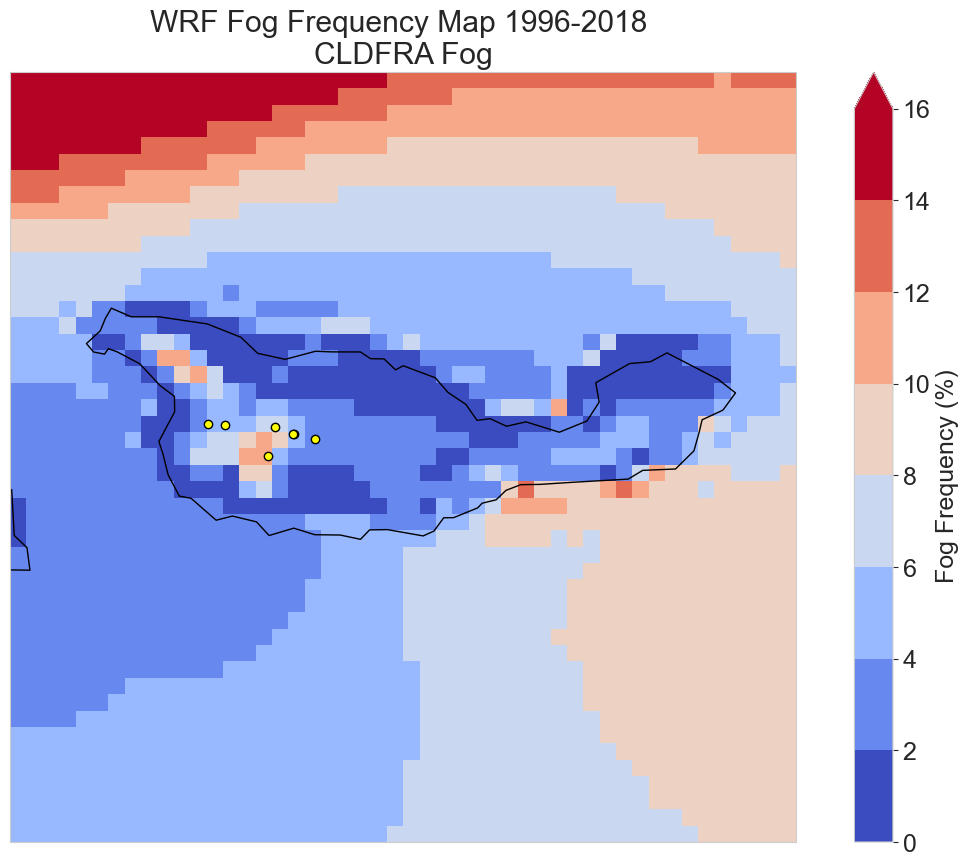

In [21]:
min_year = int(wrf_fog_ds['time'].min().dt.year)
max_year = int(wrf_fog_ds['time'].max().dt.year)

ds_gp = wrf_fog_ds['wrf-fog-binary'].sum('time')
ds_gp_count = wrf_fog_ds['wrf-fog-binary'].count('time')
ds_gp = ds_gp / ds_gp_count * 100

fig, ax = plt.subplots(figsize=(15,10), subplot_kw={'projection' : ccrs.PlateCarree()})
levels = np.arange(0, 18, 2)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

ds_gp.plot(ax=ax, cbar_kwargs={"label" : "Fog Frequency (%)"}, cmap='coolwarm', norm=norm)
ax.coastlines()
station_gdf.plot(ax=ax, color='yellow', edgecolor='black')  # Plo station coords
ax.set(title=f'WRF Fog Frequency Map {min_year}-{max_year} \nCLDFRA Fog')

plt.show()

## Annual Frequency Heat Map

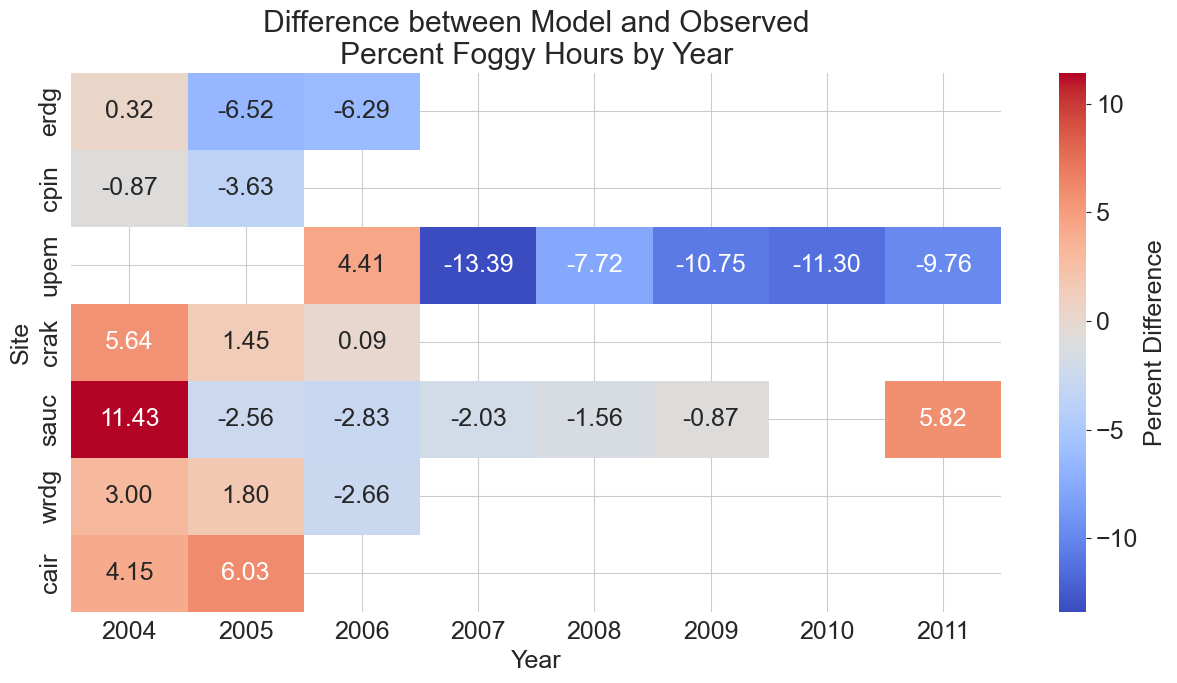

In [23]:
df_gp = join_df.groupby(['site', pd.Grouper(freq='YE', level='time (PDT)')]).sum()
df_count = join_df.groupby(['site', pd.Grouper(freq='YE', level='time (PDT)')]).count()
df_gp = df_gp / df_count * 100

df_gp = df_gp[['fog-binary', 'wrf-fog-binary']].reset_index()
df_gp['year'] = df_gp['time (PDT)'].dt.year
df_gp['diff'] =  df_gp['wrf-fog-binary'] - df_gp['fog-binary']
df_gp

site_order = ['cair', 'wrdg', 'sauc', 'crak', 'upem','cpin', 'erdg']  # Ordered West -> East
df = df_gp[['site', 'year', 'diff']]
heatmap_data = df.pivot(index='site', columns='year', values='diff')
heatmap_data = heatmap_data.loc[site_order[::-1]]  # Orders the rows by W -> E going up

fig, ax = plt.subplots(figsize=(15,7))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='coolwarm',cbar_kws={'label' : 'Percent Difference'}, ax=ax)
ax.set(title='Difference between Model and Observed\nPercent Foggy Hours by Year',
       xlabel='Year',
       ylabel='Site')
plt.show()

In [24]:
# Observed
df_gp = join_df.groupby(['site', pd.Grouper(freq='ME', level='time (PDT)')]).sum()
df_count = join_df.groupby(['site', pd.Grouper(freq='ME', level='time (PDT)')]).count()
df_gp = df_gp / df_count * 100

df_gp = df_gp[['fog-binary', 'wrf-fog-binary']].reset_index()
df_gp['year'] = df_gp['time (PDT)'].dt.year
df_gp['diff'] =  df_gp['wrf-fog-binary'] - df_gp['fog-binary']
df_gp

site_order = ['cair', 'wrdg', 'sauc', 'crak', 'upem','cpin', 'erdg']  # Ordered West -> East
df = df_gp[['site', 'time (PDT)', 'fog-binary', 'diff']]
df.head()

,site,time (PDT),fog-binary,diff
0,cair,2004-05-31,0.537634,0.537634
1,cair,2004-06-30,0.000000,4.166667
2,cair,2004-07-31,0.134590,7.671602
3,cair,2004-08-31,0.268817,7.526882
4,cair,2004-09-30,0.000000,0.701262


## Modeled vs. Observed Scatterplot

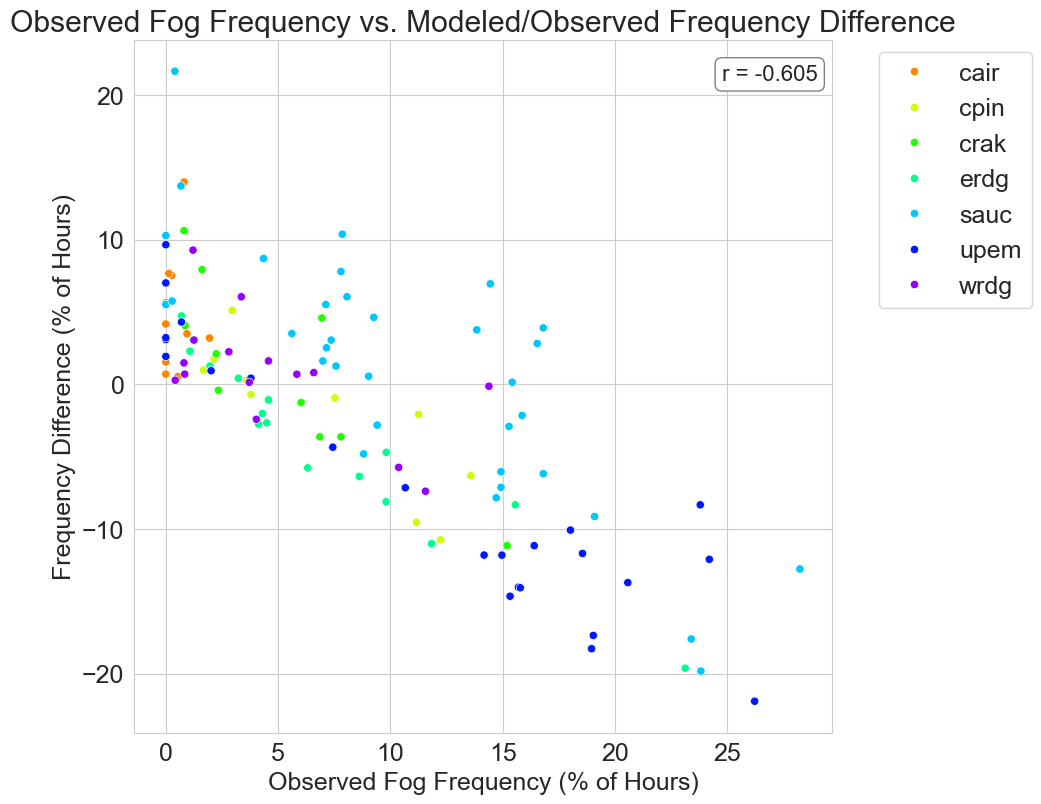

In [25]:
corr = np.corrcoef(site_df['fog-binary'], site_df['diff'])[0, 1]

fig, ax = plt.subplots(1,1, figsize=(9,9))
sns.scatterplot(df,
                x='fog-binary',
                y='diff',
                hue='site',
                palette='gist_rainbow',
                ax = ax)
ax.set(xlabel='Observed Fog Frequency (% of Hours)',
       ylabel='Frequency Difference (% of Hours)')
ax.set_title('Observed Fog Frequency vs. Modeled/Observed Frequency Difference')


# Legend
legend = ax.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')
legend.set_title(None)

# Correlation
ax.text(0.98, 0.95, f'r = {corr.round(3)}',
        transform=ax.transAxes,
        ha='right', va='center',
        fontsize=16, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))


plt.show()


## Bar plot - modeled - observed per year

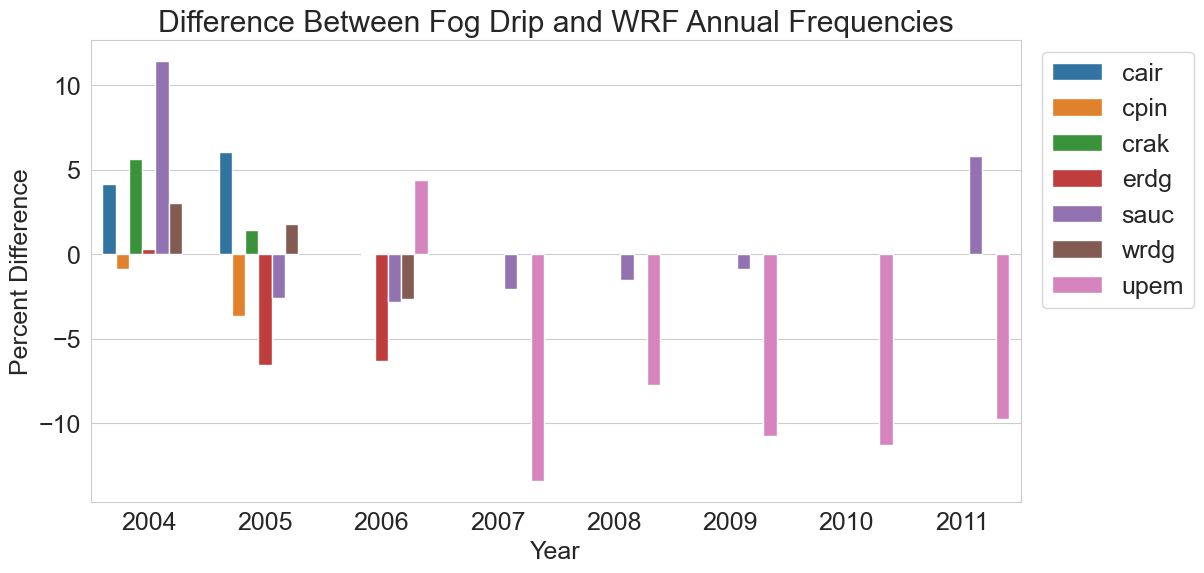

In [26]:
df_gp = join_df.groupby(['site', pd.Grouper(freq='YE', level='time (PDT)')]).sum()
df_count = join_df.groupby(['site', pd.Grouper(freq='YE', level='time (PDT)')]).count()
df_gp = df_gp / df_count * 100

df_gp = df_gp[['fog-binary', 'wrf-fog-binary']].reset_index()
df_gp['year'] = df_gp['time (PDT)'].dt.year
df_gp['diff'] = df_gp['wrf-fog-binary'] - df_gp['fog-binary']

df_gp_long = df_gp.melt(id_vars=['site', 'time (PDT)'], value_vars=['fog-binary', 'wrf-fog-binary'],
                        var_name='source', value_name='frequency')

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(data=df_gp,
            x='year',
            y='diff',
            hue='site')
ax.set(title='Difference Between Fog Drip and WRF Annual Frequencies',
       xlabel='Year',
       ylabel='Percent Difference')

plt.legend(title='', loc='upper right', bbox_to_anchor=(1.2,1))

plt.show()

## Time series plots

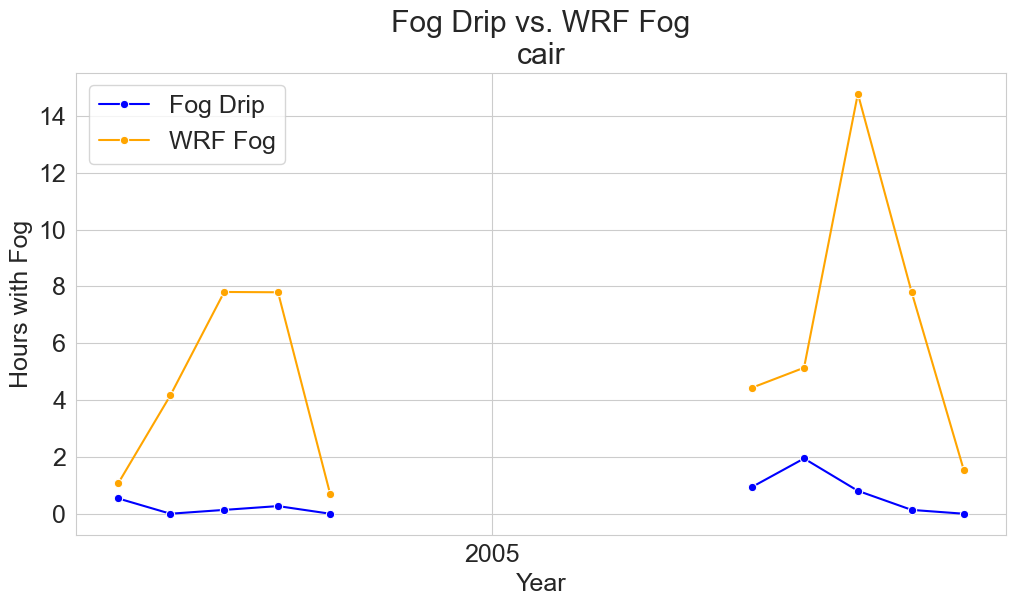

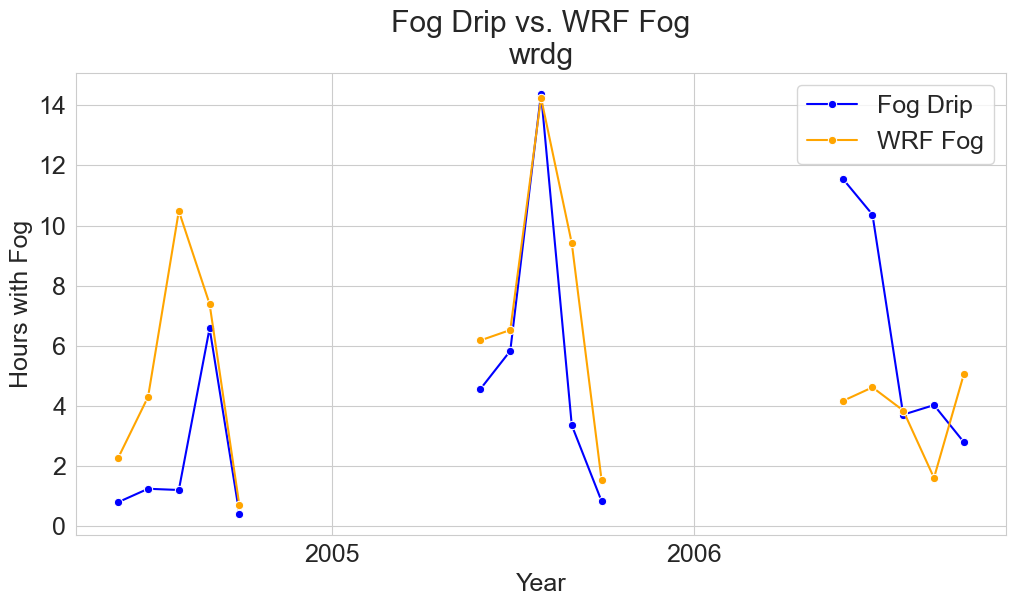

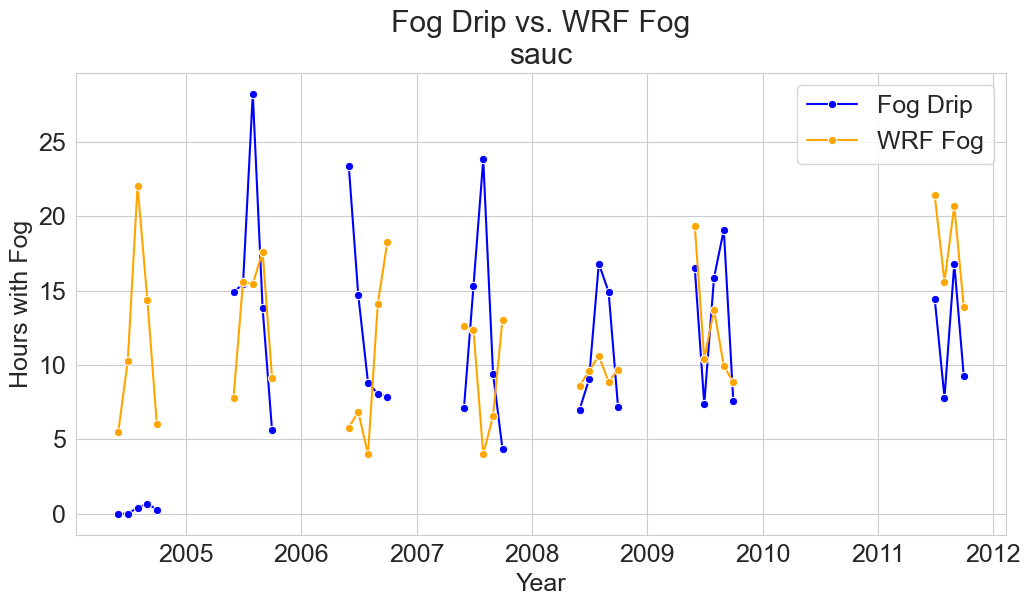

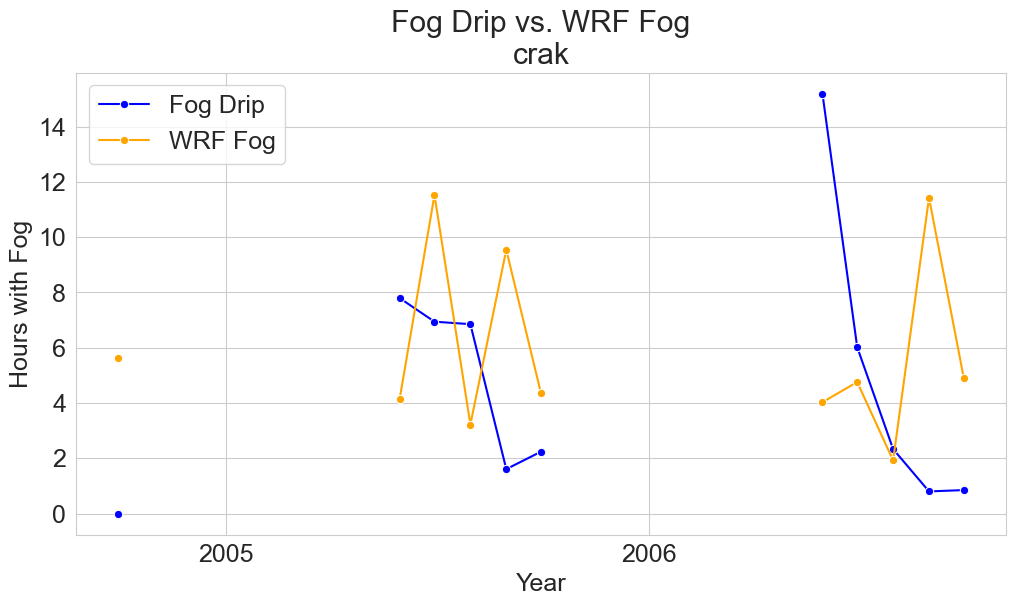

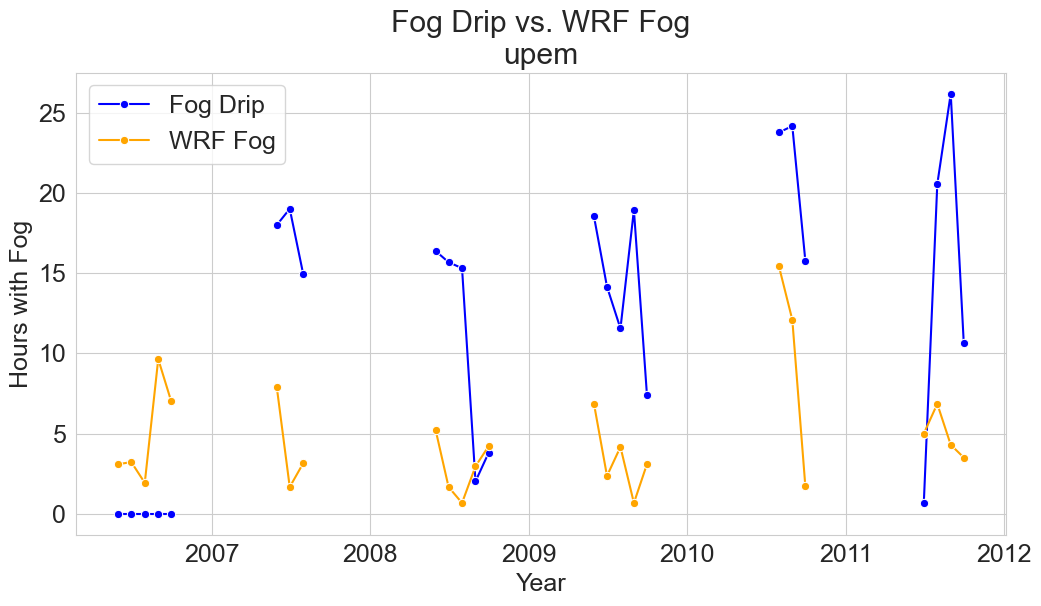

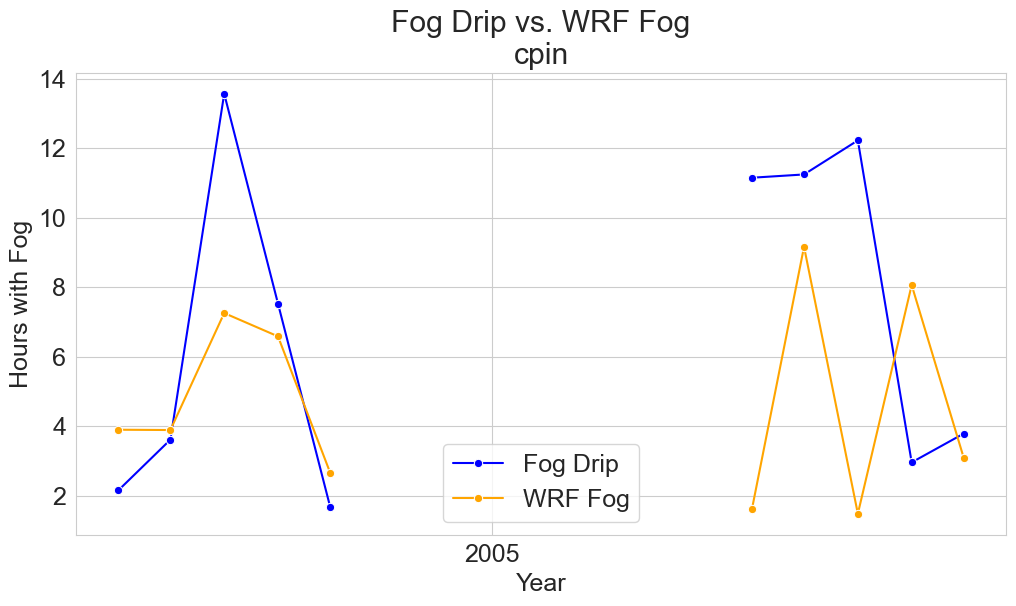

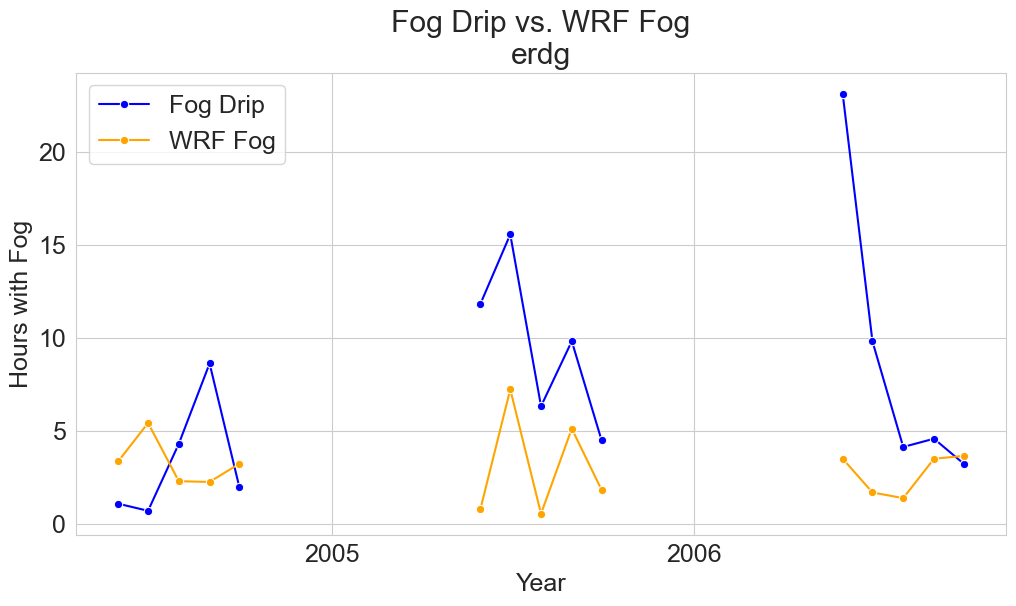

In [27]:
# Aggregate to months/years
df_gp = join_df.groupby(['site', pd.Grouper(freq='ME', level='time (PDT)')]).sum()
df_count = join_df.groupby(['site', pd.Grouper(freq='ME', level='time (PDT)')]).count()
df_gp = df_gp / df_count * 100

df_gp = df_gp.reset_index()

for site in site_order:
    site_df_gp = df_gp.loc[df_gp['site'] == site]

    fig, ax = plt.subplots(figsize=(12,6))
    display_legend=True
    for _, group in site_df_gp.groupby(site_df_gp['time (PDT)'].dt.year):
        sns.lineplot(data=group, x='time (PDT)', y='fog-binary', marker='o', color='blue', label='Fog Drip', legend=display_legend)
        sns.lineplot(data=group, x='time (PDT)', y='wrf-fog-binary', marker='o', color='orange', label='WRF Fog', legend=display_legend)
        display_legend=False
    ax.set(title=f'Fog Drip vs. WRF Fog\n{site}',
        xlabel='Year',
        ylabel='Hours with Fog')

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.show()

## Confusion Matrix Comparison
This compares timesteps - which may be a higher resolution than makes sense for our application. 

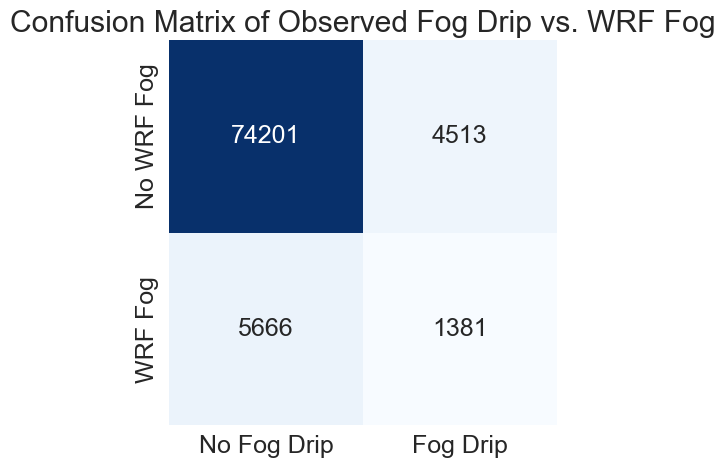

In [28]:
fig, ax = plt.subplots(figsize=(5,5))
cm = confusion_matrix(join_df['fog-binary'], join_df['wrf-fog-binary'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Fog Drip', 'Fog Drip'], yticklabels=['No WRF Fog', 'WRF Fog'], ax=ax)
ax.set(title='Confusion Matrix of Observed Fog Drip vs. WRF Fog')

# Show the plot
plt.show()

## Case Studies
Look at specific periods of time.

In [29]:
# Identify days to look at
df_gp = join_df.groupby(['site', pd.Grouper(freq='D', level='time (PDT)')]).sum()
df_count = join_df.groupby(['site', pd.Grouper(freq='D', level='time (PDT)')]).count()
df_gp = df_gp / df_count * 100

df_gp = df_gp[['fog-binary', 'wrf-fog-binary']].reset_index()
df_gp['diff'] =  df_gp['wrf-fog-binary'] - df_gp['fog-binary']
df_gp_nz = df_gp.loc[df_gp['fog-binary'] != 0]  # Subset to only days with fog

# Closest match
print(df_gp_nz.loc[(df_gp_nz['diff'] == 0) & (df_gp_nz['fog-binary'] > 50)])

# Overprediction

print(df_gp_nz.loc[df_gp_nz['diff'] == df_gp_nz['diff'].max()])

# Underprediction
print(df_gp_nz.loc[df_gp_nz['diff'] == df_gp_nz['diff'].min()])



      site time (PDT)  fog-binary  wrf-fog-binary  diff
2236  sauc 2009-07-28   54.166667       54.166667   0.0
2367  sauc 2011-08-06   58.333333       58.333333   0.0
      site time (PDT)  fog-binary  wrf-fog-binary       diff
1467  sauc 2004-07-22    4.166667       58.333333  54.166667
      site time (PDT)  fog-binary  wrf-fog-binary       diff
1577  sauc 2005-06-09   79.166667             0.0 -79.166667


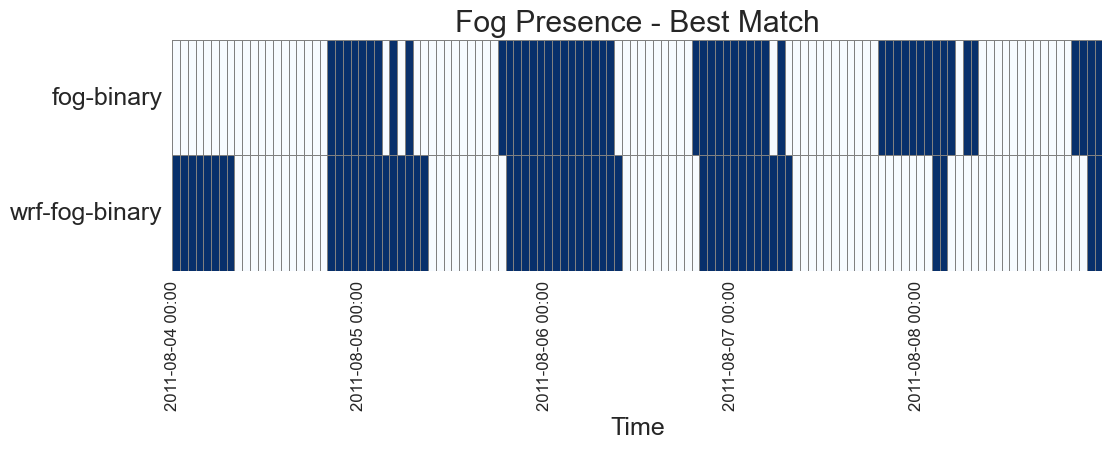

In [30]:
# Best match
df = join_df.loc['sauc'].loc['2011-08-04':'2011-08-8']
df = df[['fog-binary', 'wrf-fog-binary']].T

fig, ax = plt.subplots(figsize=(12,3))
sns.heatmap(df, cmap='Blues', cbar=False, linewidths=0.5, linecolor='gray', ax=ax)

formatted_labels = [
    ts.strftime('%Y-%m-%d %H:%M') if i % 24 == 0 else '' 
    for i, ts in enumerate(df.columns)
]

plt.xlabel('Time')
plt.title('Fog Presence - Best Match')

ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(formatted_labels, rotation=90, fontsize=12)

plt.show()

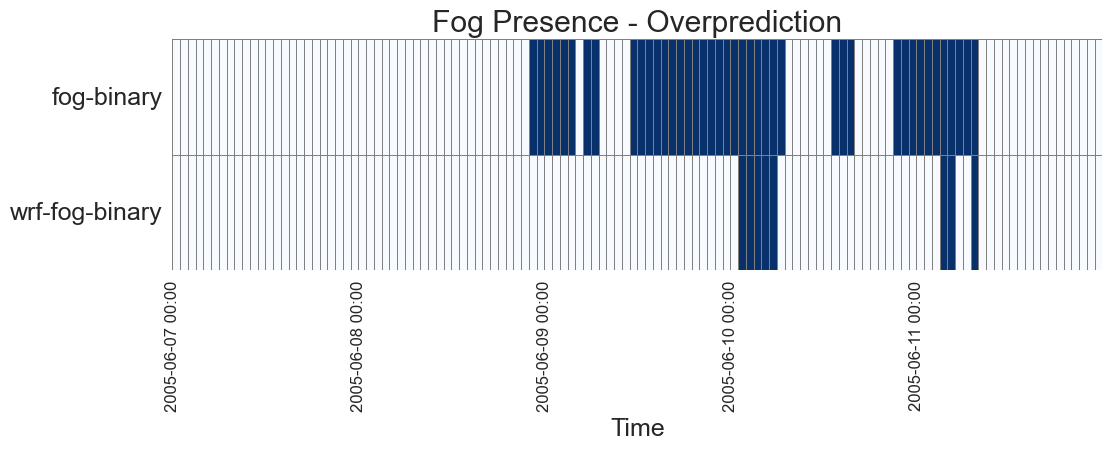

In [31]:
# Overprediction
df = join_df.loc['sauc'].loc['2005-06-07':'2005-06-11']
df = df[['fog-binary', 'wrf-fog-binary']].T

fig, ax = plt.subplots(figsize=(12,3))
sns.heatmap(df, cmap='Blues', cbar=False, linewidths=0.5, linecolor='gray', ax=ax)

formatted_labels = [
    ts.strftime('%Y-%m-%d %H:%M') if i % 24 == 0 else '' 
    for i, ts in enumerate(df.columns)
]

plt.xlabel('Time')
plt.title('Fog Presence - Overprediction')

ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(formatted_labels, rotation=90, fontsize=12)

plt.show()

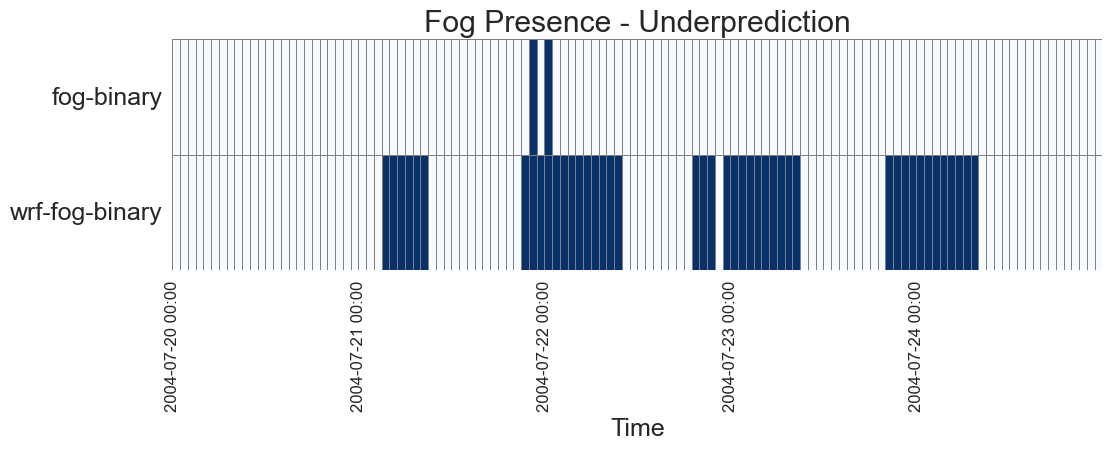

In [32]:
# Underprediction
df = join_df.loc['sauc'].loc['2004-07-20':'2004-07-24']
df = df[['fog-binary', 'wrf-fog-binary']].T

fig, ax = plt.subplots(figsize=(12,3))
sns.heatmap(df, cmap='Blues', cbar=False, linewidths=0.5, linecolor='gray', ax=ax)

formatted_labels = [
    ts.strftime('%Y-%m-%d %H:%M') if i % 24 == 0 else '' 
    for i, ts in enumerate(df.columns)
]

plt.xlabel('Time')
plt.title('Fog Presence - Underprediction')

ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(formatted_labels, rotation=90, fontsize=12)

plt.show()